<a href="https://colab.research.google.com/github/shahidhassanbtk-sys/machine-learning-project/blob/main/House_Price_Prediction_Pakistan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# House Price Prediction in Pakistan
Predicting house prices in Lahore, Karachi and Islamabad using regression models.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data.csv")  # use your real file name
df.head()

,Location,Area,Baths,Beds,Dining Room,Laundry Room,Store Rooms,Kitchens,Drawing Room,Gym,Powder Room,Steam Room,No additional rooms,Prayer Rooms,Lounge or Sitting Room,Price
0,"Bahria Town, Lahore, Punjab",10 Marla,-,-,0,0,0,0,0,0,0,0,1,0,0,PKR3.5 Crore
1,"Al Rehman Garden, Lahore, Punjab",4 Marla,4,3,1,1,1,2,1,0,0,0,0,1,0,PKR1.32 Crore
2,"Central Park Housing Scheme, Lahore, Punjab",5 Marla,4,3,0,0,0,0,0,0,0,0,1,0,0,PKR1.74 Crore
3,"DHA Defence, Lahore, Punjab",1 Kanal,6,5,0,0,0,0,0,0,0,0,0,0,0,PKR10.3 Crore
4,"DHA Defence, Lahore, Punjab",1 Kanal,6,5,1,1,2,2,1,0,1,1,0,1,1,PKR8.25 Crore


### Dataset Size
Checking how many rows and columns the dataset has.

In [ ]:
print(df.shape)

(7500, 16)


### Column Types and Missing Values
Checking each column's data type and whether it has missing values.



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Location                7500 non-null   object
 1   Area                    7500 non-null   object
 2   Baths                   7500 non-null   object
 3   Beds                    7500 non-null   object
 4   Dining Room             7500 non-null   int64 
 5   Laundry Room            7500 non-null   int64 
 6   Store Rooms             7500 non-null   int64 
 7   Kitchens                7500 non-null   int64 
 8   Drawing Room            7500 non-null   int64 
 9   Gym                     7500 non-null   int64 
 10  Powder Room             7500 non-null   int64 
 11  Steam Room              7500 non-null   int64 
 12  No additional rooms     7500 non-null   int64 
 13  Prayer Rooms            7500 non-null   int64 
 14  Lounge or Sitting Room  7500 non-null   int64 
 15  Pric

### Summary Statistics
Checking the count, mean, minimum, maximum and quartiles of the numeric columns.

In [ ]:
df.describe()

,Dining Room,Laundry Room,Store Rooms,Kitchens,Drawing Room,Gym,Powder Room,Steam Room,No additional rooms,Prayer Rooms,Lounge or Sitting Room
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,0.623200,0.468800,0.649333,1.161200,0.647867,0.256133,0.505333,0.348000,0.177333,0.413867,0.548267
std,0.484616,0.499059,0.971918,1.020533,0.477667,0.436525,0.500005,0.476368,0.381976,0.492558,0.497698
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
75%,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000
max,1.000000,1.000000,32.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Missing Values
Checking how many empty cells each column has.

In [ ]:
print(df.isnull().sum())

Location                  0
Area                      0
Baths                     0
Beds                      0
Dining Room               0
Laundry Room              0
Store Rooms               0
Kitchens                  0
Drawing Room              0
Gym                       0
Powder Room               0
Steam Room                0
No additional rooms       0
Prayer Rooms              0
Lounge or Sitting Room    0
Price                     0
dtype: int64


### Duplicate Rows
Checking for listings that appear more than once.

In [ ]:
print(df.duplicated().sum())

1237


### First Cleaning Attempt
Initial generic cleaning: drop duplicates, fill missing numbers with the median, and encode text columns. This was replaced by the full cleaning code below, which handles the Price, Area and Location formats correctly.

In [ ]:
df = df.drop_duplicates()

In [ ]:
df = df.fillna(df.median(numeric_only=True))

In [ ]:
df = pd.get_dummies(df, drop_first=True)

## 2. Data Cleaning
The raw data is cleaned so it can be used for modeling:

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("data.csv")
df = df.drop_duplicates()

# Price -> number (PKR)
def parse_price(s):
    num = float(s.replace("PKR", "").split()[0].replace(",", ""))
    return num * (10_000_000 if "Crore" in s else 100_000 if "Lakh" in s else 1)
df["Price"] = df["Price"].apply(parse_price)

# Area -> Marla
def parse_area(s):
    val, unit = float(s.split()[0].replace(",", "")), " ".join(s.split()[1:])
    if "Kanal" in unit: return val * 20
    if "Sq. Yd" in unit: return val / 30.25
    if "Sq. M" in unit: return val / 25.29
    return val  # Marla
df["Area_Marla"] = df["Area"].apply(parse_area)
df = df.drop(columns="Area")

# Beds/Baths -> numbers
for c in ["Beds", "Baths"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
    df[c] = df[c].fillna(df[c].median())

# City feature
df["City"] = df["Location"].str.split(",").str[-2].str.strip()
df = df.drop(columns="Location")
df = pd.get_dummies(df, columns=["City"], drop_first=True)

print(df.shape)
df.head()

(6263, 17)


,Baths,Beds,Dining Room,Laundry Room,Store Rooms,Kitchens,Drawing Room,Gym,Powder Room,Steam Room,No additional rooms,Prayer Rooms,Lounge or Sitting Room,Price,Area_Marla,City_Karachi,City_Lahore
0,6.0,5.0,0,0,0,0,0,0,0,0,1,0,0,35000000.0,10.0,False,True
1,4.0,3.0,1,1,1,2,1,0,0,0,0,1,0,13200000.0,4.0,False,True
2,4.0,3.0,0,0,0,0,0,0,0,0,1,0,0,17400000.0,5.0,False,True
3,6.0,5.0,0,0,0,0,0,0,0,0,0,0,0,103000000.0,20.0,False,True
4,6.0,5.0,1,1,2,2,1,0,1,1,0,1,1,82500000.0,20.0,False,True


### Checking Price, Area, Beds and Baths
Looking at the summary statistics and the price distribution after cleaning.

              Price   Area_Marla         Beds        Baths
count  6.263000e+03  6263.000000  6263.000000  6263.000000
mean   8.226454e+07    14.029273     4.909468     5.195274
std    1.048367e+08    13.534829     1.476726     1.171918
min    1.000000e+00     0.200000     1.000000     1.000000
25%    2.450000e+07     5.024793     4.000000     4.000000
50%    5.000000e+07    10.000000     5.000000     6.000000
75%    9.500000e+07    20.000000     6.000000     6.000000
max    9.700000e+08   400.000000    25.000000    10.000000


<Axes: >

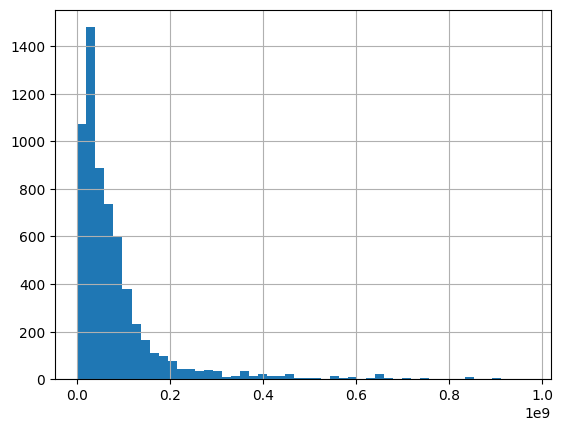

In [ ]:
print(df[["Price", "Area_Marla", "Beds", "Baths"]].describe())
df["Price"].hist(bins=50)

## 3. Train and Test Split
Separating the features (X) from the target (Price).

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("Price", axis=1)
y = np.log1p(df["Price"])   # log makes the skewed price easier to model

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 4. Baseline Model: Linear Regression
Training a simple Linear Regression model first, as a baseline to compare stronger models against.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

lr = LinearRegression()
lr.fit(X_train, y_train)
pred = lr.predict(X_test)

print("R2:", r2_score(y_test, pred))
print("MAE (PKR):", mean_absolute_error(np.expm1(y_test), np.expm1(pred)))

R2: 0.17913931264926863
MAE (PKR): 47081419.33245064


## 5. Random Forest Model
Training a Random Forest, an ensemble of 200 decision trees. Unlike Linear Regression, it can capture non-linear relationships between features and price (for example, price rising faster for very large plots).

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print("RF R2:", r2_score(y_test, pred_rf))
print("RF MAE (PKR):", mean_absolute_error(np.expm1(y_test), np.expm1(pred_rf)))

RF R2: 0.6819162624710504
RF MAE (PKR): 24958257.824681144


### Feature Importance
Checking which features the Random Forest relies on most when predicting price. Longer bars mean the feature has more influence on the prediction.

<Axes: >

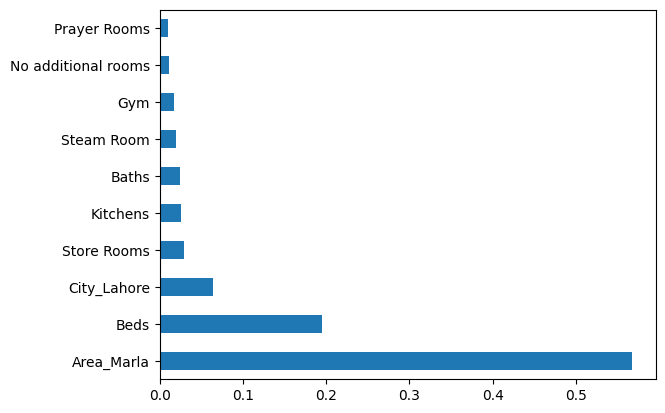

In [ ]:
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
imp.head(10).plot(kind="barh")

## 6. Adding Neighborhood
Price depends heavily on the neighborhood (for example DHA vs Kahna), but so far the model only knows the city. This step adds the neighborhood as a feature:

In [ ]:
raw = pd.read_csv("data.csv").drop_duplicates()

df2 = df.copy()
raw = raw.loc[df2.index]  # same rows as your cleaned df

hood = raw["Location"].str.split(",").str[0].str.strip()
top = hood.value_counts().head(30).index          # keep the 30 most common
df2["Neighborhood"] = hood.where(hood.isin(top), "Other")
df2 = pd.get_dummies(df2, columns=["Neighborhood"], drop_first=True)

X = df2.drop("Price", axis=1)
y = np.log1p(df2["Price"])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf2 = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf2.fit(X_train, y_train)
pred2 = rf2.predict(X_test)

print("RF + Neighborhood R2:", r2_score(y_test, pred2))
print("MAE (PKR):", mean_absolute_error(np.expm1(y_test), np.expm1(pred2)))

RF + Neighborhood R2: 0.6930044960646284
MAE (PKR): 19676100.68528305


### Predicted vs Actual Prices
Comparing the model's predictions with the real prices on the test set. Each dot is one house. The red dashed line marks perfect predictions, so the closer a dot is to the line, the better the prediction.

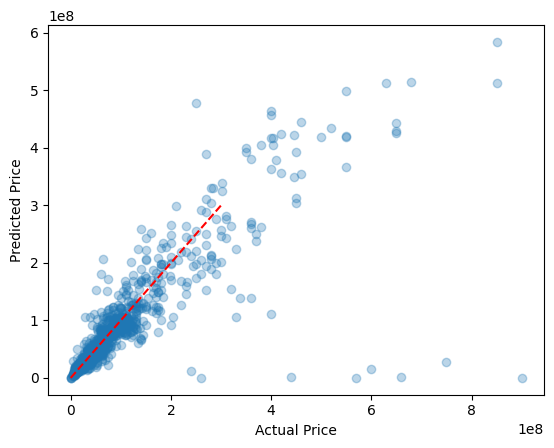

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(np.expm1(y_test), np.expm1(pred2), alpha=0.3)
plt.plot([0, 3e8], [0, 3e8], "r--")
plt.xlabel("Actual Price"); plt.ylabel("Predicted Price")
plt.show()

### Typical Error vs Typical Price
The average error (MAE) is pulled up by a few very expensive houses, so the median is a fairer measure. Here the median house price is compared with the median absolute error.

In [ ]:
print("Median price:", df["Price"].median())
print("Median abs error:", np.median(np.abs(np.expm1(y_test) - np.expm1(pred2))))

Median price: 50000000.0
Median abs error: 5484390.419653112


### Investigating Extreme Errors
Listing the 10 test-set houses where the model's prediction was furthest from the real price, to understand what causes the largest errors. Then the top 1% of prices are marked as outliers and removed to create a cleaner dataset (`df_clean`).

In [ ]:
# 1. Look at the extreme outliers
out = df2.loc[y_test.index].copy()
out["actual"] = np.expm1(y_test)
out["pred"] = np.expm1(pred2)
out["error"] = (out["actual"] - out["pred"]).abs()
print(out.sort_values("error", ascending=False)[["Area_Marla", "Beds", "actual", "pred"]].head(10))

# 2. Remove extreme price outliers, then retrain
q = df["Price"].quantile(0.99)
df_clean = df2[df2["Price"] <= q]

      Area_Marla  Beds        actual          pred
6605   80.000000   8.0  9.000000e+08  2.662096e+04
4956  132.231405   6.0  7.500000e+08  2.836194e+07
7248   32.000000   7.0  6.600000e+08  1.416426e+06
5492   50.000000   8.0  6.000000e+08  1.607560e+07
812    80.000000  10.0  5.700000e+08  1.969205e+04
6002   38.000000   8.0  4.400000e+08  7.373791e+05
7174   40.000000   6.0  8.500000e+08  5.122854e+08
5417   20.000000   7.0  4.000000e+08  1.109958e+08
5088   50.000000   8.0  8.500000e+08  5.843141e+08
337    80.000000  10.0  2.600000e+08  2.092653e+04


## 7. Removing Outliers and Comparing Models
The top 1% of prices are removed because they are extreme, rare listings that the models cannot learn from. Then the data is split again (80/20) and three models are trained and compared on the same test set:

- **Linear Regression:** simple baseline
- **Random Forest:** ensemble of 200 decision trees
- **Gradient Boosting:** trees built one after another, each correcting the errors of the previous one

Metrics: **R²** (higher is better), **MAE** (average error) and **Median Error** (typical error, less affected by expensive houses).

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# 1. Remove extreme price outliers (top 1%) and tiny-area/huge-price errors
q = df2["Price"].quantile(0.99)
df_clean = df2[df2["Price"] <= q].copy()
print("Rows before:", len(df2), "| after:", len(df_clean))

# 2. Split again
X = df_clean.drop("Price", axis=1)
y = np.log1p(df_clean["Price"])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train three models and compare
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

results = []
for name, m in models.items():
    m.fit(X_train, y_train)
    p = m.predict(X_test)
    actual, predicted = np.expm1(y_test), np.expm1(p)
    results.append({
        "Model": name,
        "R2": round(r2_score(y_test, p), 3),
        "MAE (PKR)": round(mean_absolute_error(actual, predicted)),
        "Median Error (PKR)": round(np.median(np.abs(actual - predicted))),
    })

results_df = pd.DataFrame(results)
results_df

Rows before: 6263 | after: 6205


,Model,R2,MAE (PKR),Median Error (PKR)
0,Linear Regression,0.296,31394953,12981864
1,Random Forest,0.644,14659774,5282426
2,Gradient Boosting,0.640,18993635,7220615


## Predicted vs Actual Price

This section compares the actual house prices with the prices predicted by the best-performing Random Forest model after removing outliers.

The scatter plot shows the relationship between actual and predicted prices. The red dashed line represents perfect predictions, where the predicted price is equal to the actual price.

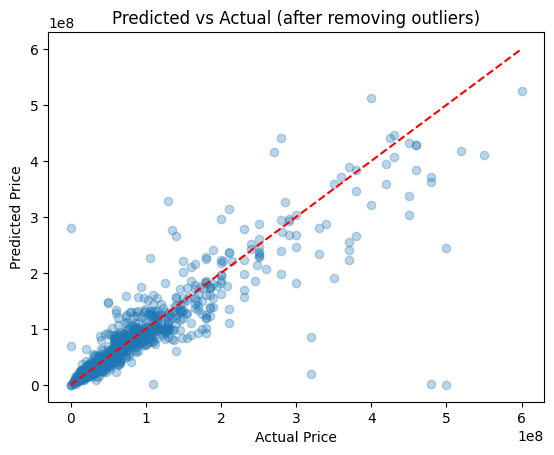

In [ ]:
best = models["Random Forest"]
pred_best = np.expm1(best.predict(X_test))
actual = np.expm1(y_test)

plt.scatter(actual, pred_best, alpha=0.3)
lim = max(actual.max(), pred_best.max())
plt.plot([0, lim], [0, lim], "r--")
plt.xlabel("Actual Price"); plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual (after removing outliers)")
plt.show()

## Cross-Validation of Random Forest Model

This section evaluates the Random Forest model using 5-fold cross-validation. The R² score is calculated for each fold, and the mean R² score is used to summarize the model's performance across all five folds.

In [ ]:
from sklearn.model_selection import cross_val_score

cv = cross_val_score(
    RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    X, y, cv=5, scoring="r2"
)
print("R2 per fold:", cv.round(3))
print("Mean R2:", cv.mean().round(3))

R2 per fold: [0.662 0.047 0.831 0.718 0.692]
Mean R2: 0.59


## House Price Prediction for a Sample Property

This section uses one existing property as a template and changes its area, number of bedrooms, and number of bathrooms. The trained Random Forest model is then used to predict the property's price.

In [ ]:
sample = X.iloc[[0]].copy()          # copy an existing row as a template
print(sample.T.head(15))             # see what the columns look like

sample["Area_Marla"] = 10
sample["Beds"] = 4
sample["Baths"] = 4

price = np.expm1(best.predict(sample))[0]
print(f"Predicted price: PKR {price/1e7:.2f} Crore")

                            0
Baths                     6.0
Beds                      5.0
Dining Room                 0
Laundry Room                0
Store Rooms                 0
Kitchens                    0
Drawing Room                0
Gym                         0
Powder Room                 0
Steam Room                  0
No additional rooms         1
Prayer Rooms                0
Lounge or Sitting Room      0
Area_Marla               10.0
City_Karachi            False
Predicted price: PKR 3.55 Crore


## Saving the Model Results and Trained Model

This section saves the model evaluation results as a CSV file and saves the trained Random Forest model as a `.pkl` file. The saved model can be loaded later without training the model again.

In [ ]:
results_df.to_csv("model_results.csv", index=False)

import joblib
joblib.dump(best, "house_price_model.pkl")

['house_price_model.pkl']

## Final Model Results and Cross-Validation Summary

This section displays the model evaluation results, the R² scores from 5-fold cross-validation, the mean cross-validation R² score, and the total number of rows used after data cleaning.

In [ ]:
print(results_df.to_string(index=False))
print("\nCross-validation R2:", cv.round(3), "| Mean:", cv.mean().round(3))
print("Rows used:", len(df_clean))

            Model    R2  MAE (PKR)  Median Error (PKR)
Linear Regression 0.296   31394953            12981864
    Random Forest 0.644   14659774             5282426
Gradient Boosting 0.640   18993635             7220615

Cross-validation R2: [0.662 0.047 0.831 0.718 0.692] | Mean: 0.59
Rows used: 6205


## 5-Fold Cross-Validation with Random Forest

This section evaluates the Random Forest model using 5-fold cross-validation. The dataset is divided into five parts, and the model is tested on each fold. The R² score for each fold and the mean R² score are displayed to evaluate the model's performance.

In [ ]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv = cross_val_score(
    RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    X, y, cv=kf, scoring="r2"
)
print("R2 per fold:", cv.round(3), "| Mean:", cv.mean().round(3))

R2 per fold: [0.648 0.605 0.777 0.744 0.832] | Mean: 0.721
